## Example 3.1 : Interference of two circular sine waves

### What you will learn

In this notebook, we:
- simulate the interference pattern of two circular wave sources in 2D
- visualize the resulting wave field
- derive the analytical structure of the interference pattern

In particular, we show that:
- the nodal lines correspond to ellipses and hyperbolas
- the numerical results are consistent with theoretical predictions

### Situation
Consider two circular waves in two dimensions, whose centers are located at different points, $(x,y)=(\pm\frac{d}{2}, 0)$.  

### Task
Superimpose the two waves and plot the resulting wave.  

Assumption: 
 - We ignore amplitude decay and time-dependence,  and approximate each of the circular wave simply by $\sin(kr)$, where $k$ is the wave number and $r$ is the distance from the center of the wave.  (The physically more reasonable form will be such as $\frac{1}{\sqrt{r}}\sin(kr-\omega t)$, but we make simplicity above; the essense will not be lost.)
 - Both waves have the same amplitude (that is, they are identical except for their center positions).  

### Setup
We place the entire system within a square with side length $L$, with its corners located at $(\pm L/2,\pm L/2)$.  
We discretize the space with $(N+1, N+1)$ grid points (i.e., the distance of grid points is given by $\delta=L/N$).   

### parameters:

| symbol | default values | meaning |
| ------ | ------- | -------------- |
| $L$ | 100 | the system length |
| $N$ | 1000| the number of grid points per side |
| $d$ | 20 | the distance between centers of the waves|
| $k$| $2\pi/5.0$ | the wave number |

## Plot

The resulting superimposed wave is $\sin(kr_1)+\sin(kr_2)$, where $r_1$ is the distance from the center $(-\frac{d}{2}, 0)$ and $r_2$ from the center $(\frac{d}{2}, 0)$.  
Let us plot it as a countour color map. 

In [1]:
import numpy as np
from numpy import pi as pi
import math
import matplotlib.pyplot as plt

In [2]:
# set parameters 
L = 100
N= 1000
d = 20
k = 2*pi/5.25

delta = L/N

In [3]:
# set up grids
xx = np.linspace(-L/2,L/2, N+1)
yy = np.linspace(-L/2,L/2, N+1)
x, y = np.meshgrid(xx, yy)

In [4]:
# create waves
x1, y1 = (-d/2, 0)
x2, y2 = (d/2, 0)
r1 = np.sqrt((x-x1)**2 + (y-y1)**2)
r2 = np.sqrt((x-x2)**2 + (y-y2)**2)
wave1 = np.sin(k*r1)
wave2 = np.sin(k*r2)
wave = wave1 + wave2

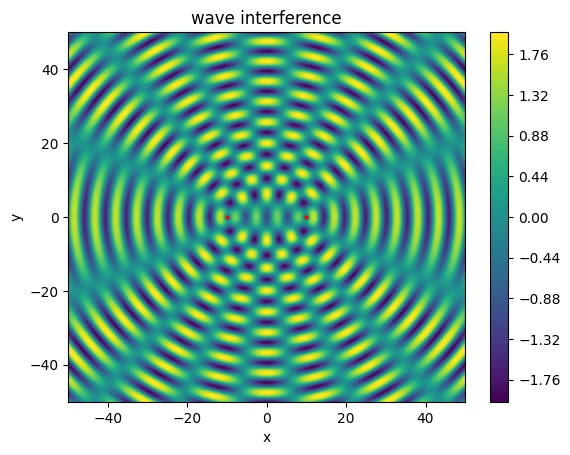

In [5]:
# show wave
plt.contourf(x, y, wave, levels=100, cmap='viridis')  # levels+1 is the number of discretization of the value
plt.plot(x1, y1, 'ro', markersize=2)
plt.plot(x2, y2, 'ro', markersize=2)
plt.colorbar()
plt.title('wave interference')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

**There appear some patterns, in particular radial pattern of value=0 points.  What is this?   Let us look at its theoretical background.**

## Theoretical analysis:

Since $\sin(kr_1) + \sin(kr_2) = 2\sin(\frac{k}{2}(r_1+r_2))\cos(\frac{k}{2}(r_1-r_2))$, the zero points of the wave can be divided to two groups. 

### Ellipses   
$\frac{k}{2}(r_1+r_2) = n\pi$ with n an integer.  Since $r_1+r_2\geq d$, the minimum value of $n$ is $n_{\rm min} = {\rm ceil}(\frac{kd}{2\pi})$.

Generally, an ellipse with foci $x=-f$ and $x=f$ and the sum of distance $2a$ is described as $\frac{x^2}{a^2}+\frac{y^2}{b^2}=1$ with $b^2=a^2-f^2$.  
The parametric representation is $x=a\cos(t), y=b\sin(t)$.  
In our case, $f=\frac{d}{2}$ and $a=\frac{n\pi}{k}$.

### Hyperbolas  
$\frac{k}{2}(r_1-r_2) = (n+\frac{1}{2})\pi$ with n an integer.  Since $r_1-r_2\leq d$, the maximum value of $n$ is $n_{\rm max} = {\rm floor}(\frac{kd}{2\pi}-\frac{1}{2})$.

Generally, a hyperbola with foci $x=-f$ and $x=f$ and the difference of distance $2a$ is described as $\frac{x^2}{a^2}-\frac{y^2}{b^2}=1$ with $b^2=f^2-a^2$.  
The parametric representation is $x=a\cosh(t), y=b\sinh(t)$.  
In our case, $f=\frac{d}{2}$ and $a=\frac{(n+\frac{1}{2})\pi}{k}$.

### Check the agreement between theory and numerical calculations
Now we plot elipses and hyperbolas described above over the wave color map, to check the agreement between theory and numerical calculation:  

In [ ]:
# show ellipses
plt.contourf(x, y, wave, levels=100, cmap='viridis') 
plt.colorbar()
plt.plot(x1, y1, 'ro', markersize=2)
plt.plot(x2, y2, 'ro', markersize=2)
n_min = math.ceil(k*d/(2*pi)) 
for n in range(n_min, n_min+15):
    t = np.linspace(0, 2*np.pi, 100)
    a = n*pi/k
    b = math.sqrt(a**2 - d**2/4)
    x_e, y_e = a*np.cos(t), b*np.sin(t)
    plt.plot(x_e, y_e, 'r', lw=1, ls='--')
plt.title('wave interference with ellipses emphasized')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [ ]:
# show hyperbolas
plt.contourf(x, y, wave, levels=100, cmap='viridis') 
plt.colorbar()
plt.plot(x1, y1, 'ro', markersize=2)
plt.plot(x2, y2, 'ro', markersize=2)
n_max = math.floor((k*d)/(2*pi) -1/2) 
for n in range(n_max+1):
    t = np.linspace(-2, 2, 100)
    a = (n+1/2)*pi/k
    b = math.sqrt(d**2/4 - a**2)
    x_h, y_h = a*np.cosh(t), b*np.sinh(t)
    plt.plot(x_h, y_h, 'r', lw=1, ls='--')
    plt.plot(-x_h, y_h, 'r', lw=1, ls='--')
plt.title('wave interference with hyperbolas emphasized')
plt.xlabel('x')
plt.ylabel('y')
plt.show()